![image.png](img/save/4.png)


In [21]:
import cv2 as cv 
import numpy as np
import matplotlib.pyplot as plt
import sys

In [ ]:
img = cv.imread('img/school.jpg')
gray = cv.cvtColor(img,cv.COLOR_BGR2GRAY)

In [ ]:
# 기존 코드 
grad_x=cv.Sobel(gray,cv.CV_32F,1,0,ksize=3)
grad_y=cv.Sobel(gray,cv.CV_32F,0,1,ksize=3)

sobel_x=cv.convertScaleAbs(grad_x)
sobel_y=cv.convertScaleAbs(grad_y)

edge_strength=cv.addWeighted(sobel_x,0.5,sobel_y,0.5,0)

h, w = gray.shape
sobel_x = cv.resize(sobel_x, (w, h))
sobel_y = cv.resize(sobel_y, (w, h))
edge_strength = cv.resize(edge_strength, (w, h))

top = cv.hconcat([gray, sobel_x])
bottom = cv.hconcat([sobel_y, edge_strength])

combined = cv.vconcat([top, bottom])
scale = 0.3
combined_small = cv.resize(combined, None, fx=scale, fy=scale)

cv.imshow('All in One', combined_small)
cv.waitKey()
cv.destroyAllWindows()

Sobel  
x방향 (수직 edge)  

 X방향   
$
\begin{bmatrix} 
-1 & 0 & 1 \\ 
-2 & 0 & 2 \\ 
-1 & 0 & 1 
\end{bmatrix} 
$

 Y방향    
$
\begin{bmatrix} 
-1 & -2 & -1 \\ 
0 & 0 & 0 \\ 
1 & 2 & 1 
\end{bmatrix} 
$

이것을 대각선 방향으로 적절히 변형해서 적용하라

Sobel  
x방향 (수직 edge)  

>/ 대각 방향    
$
\begin{bmatrix} 
0 & 1 & 2 \\ 
-1 & 0 & 1 \\ 
-2 & -1 & 0 
\end{bmatrix} 
$

>\ 대각 방향      
$
\begin{bmatrix} 
-2 & -1 & 0 \\ 
-1 & 0 & 1 \\ 
0 & 1 & 2 
\end{bmatrix} 
$

In [14]:
kernel_45 = np.array([
    [-2, -1,  0],
    [-1,  0,  1],
    [ 0,  1,  2]
], dtype=np.float32)

kernel_N45 = np.array([
    [ 0,  1,  2],
    [-1,  0,  1],
    [-2, -1,  0]
], dtype=np.float32)

In [ ]:

grad_45 = cv.filter2D(gray, cv.CV_32F, kernel_45)
grad_N45 = cv.filter2D(gray, cv.CV_32F, kernel_N45)

sobel_45 = cv.convertScaleAbs(grad_45)
sobel_N45 = cv.convertScaleAbs(grad_N45)

h, w = gray.shape

sobel_45 = cv.resize(sobel_45, (w, h))
sobel_N45 = cv.resize(sobel_N45, (w, h))
edge_com = cv.addWeighted(sobel_45, 0.3, sobel_N45, 0.3, 0)

combined = cv.hconcat([sobel_45, sobel_N45, edge_com])
combined_small = cv.resize(combined, None, fx=0.3, fy=0.3)

cv.imshow('ed', combined_small)

cv.waitKey()
cv.destroyAllWindows()


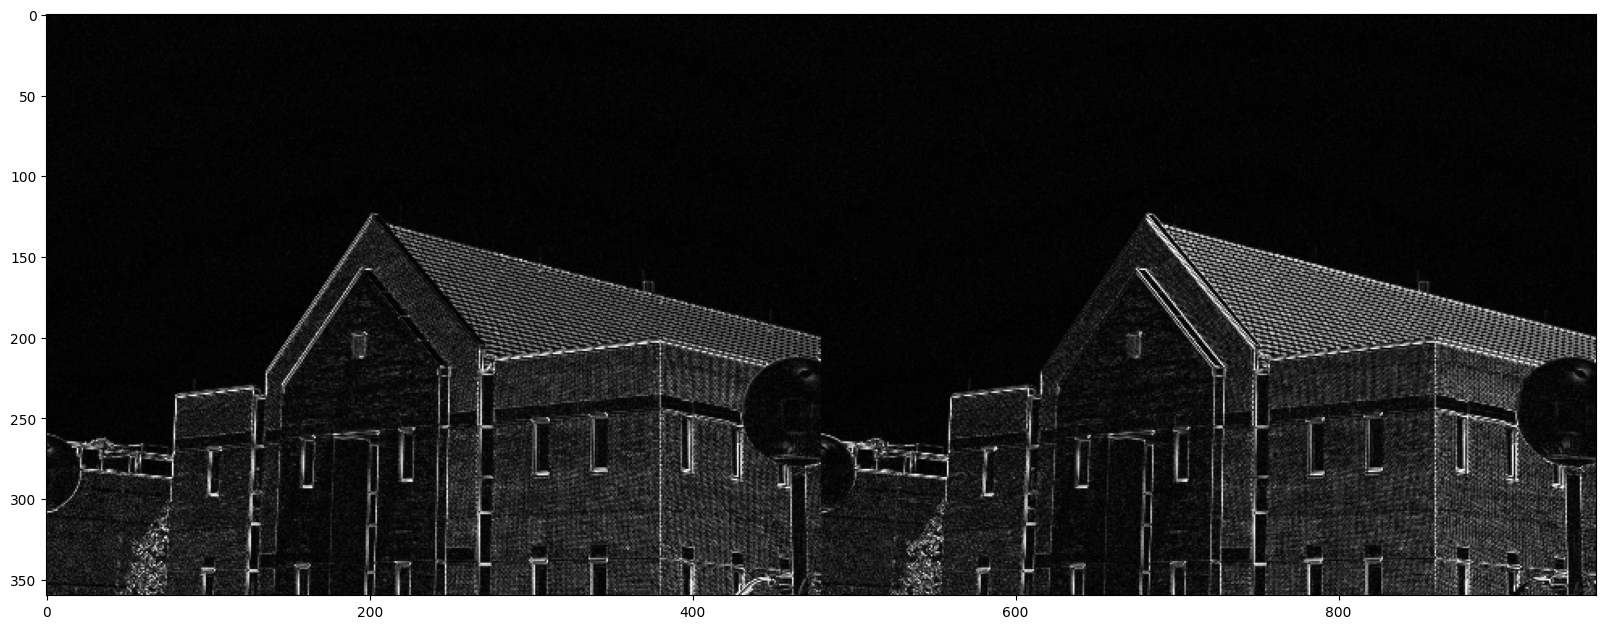

In [22]:
plt.figure(figsize=(20, 10)) 
plt.imshow(cv.cvtColor(combined_small, cv.COLOR_BGR2RGB))
plt.show() 

점점 더 밝아지는 방향이 서로 다른 것을 볼 수 있다.   
kernel_45는 좌측 대각선이 강조되어 있고   
우측 대각선의 특징을 사실상 날려버렸다.   
이는 반대도 같다  

결국 이렇게 각 특징을 잘 추출하는 용도에 맞는 커널들을 융합해   
실제로 edge가 있는지를 모두 검출해 합치는 작업이 필요할 것이다.   
물론 그 사이에 노이즈로 인한 외곡이 문제될 수 있지만 말이다.  